In [ ]:
import tensorflow as tf
from keras import layers, models
import matplotlib.pyplot as plt
from utils.load_data import load_local_cifar10, preprocess

I0000 00:00:1773977883.073784   26353 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
(x_train, y_train), (x_test, y_test) = load_local_cifar10('cifar-10-batches-py')

y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print(f"Training shapes: {x_train.shape}, {y_train.shape}")
print(f"Testing shapes: {x_test.shape}, {y_test.shape}")

/home/popboat/tensorflow_projects/AlexNet/load_data.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  batch = pickle.load(f, encoding='latin1')


Training shapes: (50000, 32, 32, 3), (50000, 10)
Testing shapes: (10000, 32, 32, 3), (10000, 10)


/home/popboat/tensorflow_projects/AlexNet/load_data.py:26: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  batch = pickle.load(f, encoding='latin1')


In [4]:
BATCH_SIZE = 16

train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = (train_dataset
                 .shuffle(8000)
                 .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
                 .batch(BATCH_SIZE)
                 .prefetch(tf.data.AUTOTUNE))

In [5]:
test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_dataset = (test_dataset
                .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
                .batch(BATCH_SIZE)
                .prefetch(tf.data.AUTOTUNE))

In [6]:
model = models.Sequential([
    	layers.RandomFlip("horizontal", input_shape=(227, 227, 3)),
    	layers.RandomRotation(0.1),
    	layers.RandomZoom(0.1),
        layers.Conv2D(96, 11, strides=4, padding='valid', activation='relu', input_shape=(227, 227, 3)),
        layers.MaxPooling2D(3, strides=2),
        
        layers.Conv2D(256, 5, strides=1, padding='same', activation='relu'),
        layers.MaxPooling2D(3, strides=2),
        
        layers.Conv2D(384, 3, strides=1, padding='same', activation='relu'),
        layers.Conv2D(384, 3, strides=1, padding='same', activation='relu'),
        layers.Conv2D(256, 3, strides=1, padding='same', activation='relu'),
        layers.MaxPooling2D(3, strides=2),
        
        layers.Flatten(),
        
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
model.summary()

/home/popboat/tensorflow_projects/myenv/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/home/popboat/tensorflow_projects/myenv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 227, 227, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 227, 227, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 227, 227, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,322,314 (222.48 MB)

 Trainable params: 58,322,314 (222.48 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=test_dataset,
    callbacks=[early_stopping]
)

Epoch 1/30


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 212s 68ms/step - accuracy: 0.7707 - loss: 0.6613 - val_accuracy: 0.7908 - val_loss: 0.6233
Epoch 2/30
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 215s 69ms/step - accuracy: 0.7824 - loss: 0.6325 - val_accuracy: 0.8052 - val_loss: 0.5784
Epoch 3/30
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 212s 68ms/step - accuracy: 0.7927 - loss: 0.5994 - val_accuracy: 0.8021 - val_loss: 0.5787
Epoch 4/30
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 227s 73ms/step - accuracy: 0.8028 - loss: 0.5692 - val_accuracy: 0.8141 - val_loss: 0.5624
Epoch 5/30
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 224s 72ms/step - accuracy: 0.8112 - loss: 0.5449 - val_accuracy: 0.8182 - val_loss: 0.5353
Epoch 6/30
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 223s 71ms/step - accuracy: 0.8214 - loss: 0.5156 - val_accuracy: 0.8173 - val_loss: 0.5394
Epoch 7/30
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 221s 71ms/step - accuracy: 0.8267 - loss: 0.5026 - val_accuracy: 0.8293 - val_loss: 0.5179
Epoch 8/30
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 218s 70ms/step - accuracy: 0.8325 - lo

In [10]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

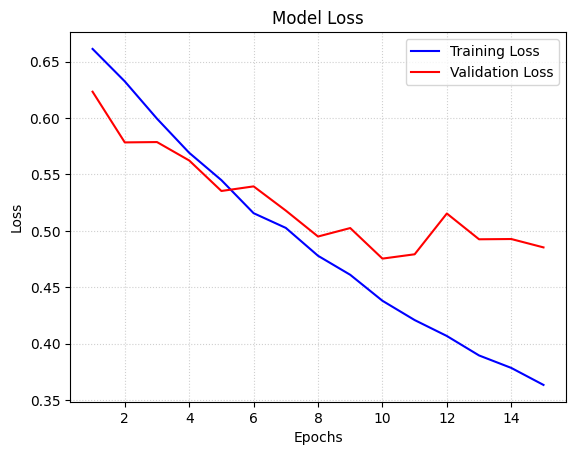

In [11]:
plt.figure()
plt.plot(epochs, loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

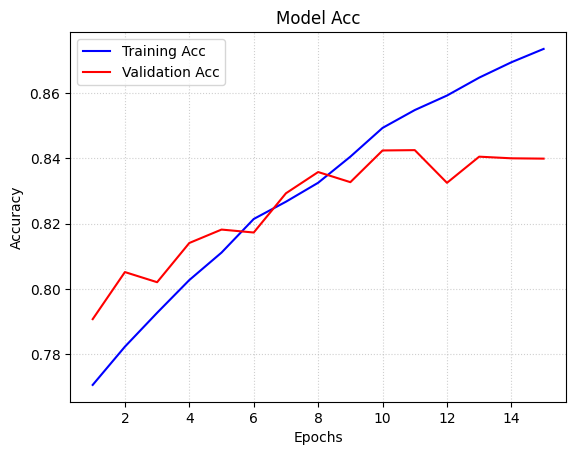

In [12]:
plt.figure()
plt.plot(epochs, acc, 'b-', label='Training Acc')
plt.plot(epochs, val_acc, 'r-', label='Validation Acc')
plt.title('Model Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [13]:
model.save('alexnet_cifar10_keras.h5')
print("Model saved successfully!")

Model saved successfully!
